### This was done in August, 2026.

# Practical Exam: Spectrum Shades LLC
Spectrum Shades LLC is a prominent supplier of concrete color solutions, offering a wide range of pigments and coloring systems used in various concrete applications, including decorative concrete, precast concrete, and concrete pavers. The company prides itself on delivering high-quality colorants that meet the unique needs of its diverse clientele, including contractors, architects, and construction companies.

The company has recently observed a growing number of customer complaints regarding inconsistent color quality in their products. The discrepancies have led to a decline in customer satisfaction and a potential increase in product returns.
By identifying and mitigating the factors causing color variations, the company can enhance product reliability, reduce customer complaints, and minimize return rates.

You are part of the data analysis team tasked with providing actionable insights to help Spectrum Shades LLC address the issues of inconsistent color quality and improve customer satisfaction.

## Exam Guidelines
- Use Python to perform each of the tasks.
- Write your solutions in the code cell provided. Each solution must be in a **SINGLE** cell.
- The final output of your query will be graded, not the code.
- Ensure you match any column name requirements.
- You must be successful in all tasks to pass this exam.
- You will only have **two** opportunities to submit your exam for grading.
- Use the code block at the bottom of the workspace to check that you have met the formatting and naming requirements for automarking.

## Summary of Findings & Recommendations
Spectrum Shades, in the interest of solving the issue of a growing number of complaints regarding inconsistent color quality in their products, wants to evaluate factors causing color variations & how they relate to product quality scores (a.k.a. customer satisfaction levels). This project explored data revolving around the production of the company's colorants & concrete color solutions including variables like production date, material supplier, pigment type, pigment quantity, mixing time, mixing speed, & product quality score. In particular, it explored & examined the relationship between pigment quantity & product quality score. There were 2,000 batches that comprised this dataset.

Following some straightforward preprocessing of the data (see **Task 1**), these two main variables of interest were aggregated across the two raw-material suppliers, which were either national or international (each had 700+ batches) (see **Task 2**). For both variables, the differences in the averages between the two groups of suppliers was quite striking.
- Products made from materials from a national supplier contained about 10 more kilograms on average than those from international suppliers.
- Products made from materials from a national supplier saw an average product-quality score that was more than two points greater than those from international suppliers.
- Moreover, compared to the overall averages, pigment quantity & quality scores of products from national suppliers were considerably above average, whereas those from international suppliers were noticeably below average.
From this data alone, it could point to a positive relationship between pigment quantity & product quality score given that this is reflected across both suppliers. Nonetheless, it is clear that products of national suppliers are rated more highly than those of international suppliers.

In **Task 3**, the data was filtered to look more closely at colorants built using materials from intenational suppliers that had more than 35 kilograms of pigment. Once more, aggregate metrics were analyzed. Despite the data being biased towards heavier quantities of pigment, these 619 batches had the same average product quality score (~5.97) as that of the 1,300 batches made from materials of international suppliers despite the average pigment quantity being about four kilograms higher. As such, it could be indicative that there is no or a weak relationship between 'pigment_quantity' & 'product_quality_score' specifically for international suppliers.

The final section, **Task 4**, analyzed the 'pigment_quantity' & 'product_quality_score' variables more directly by evaluating their distributions & their correlation. From these analyses, it appears that when more pigment is included in the business' colorants, customers are generally happier with the product. More specifically, a scatterplot was made, illustrating a clear, linear relationship between these two variables, a relationship that possesses a weak-to-moderate, positive correlation of about 0.49. In other words, the more pigment that is put into the company's products, customers are typically more satisfied with it & indicate this through a higher product quality score. To clarify, this metric does not indicate causation, but merely that the two variables change in relation to one another.


#### Recommendations
As such, the scattterplot in **Task 4** & the associated analyses offer an immediate solution for the company towards fixing their dillemma in the rising number of complaints with their products. By introducing more pigment into their products, Spectrum Shades is likely to see a rise in the quality scores of their products which should be accompanied by less complaints. Such an undertaking will hopefully begin to resolve the problem with low customer satisfaction.

When it comes to the problem of inconsistent color quality, a higher pigment concentration typically produces a brighter, more vivid result in colorants. It is unclear as to what exactly the problem of "inconsistent color quality" is, but products lacking a clear, rich, vibrant hue may be one aspect. If so, adding pigment could not only aid in the problem of low customer satisfaction but also in that of inconsistent color quality.  
If this problem does not have to do with the concentration of the business' colorants, then other factors will need to be analyzed. Perhaps such quality problems are arising due to pigment type, mixing time, mixing speed, material supplier, or how long between production & usage. Such variables, which are available in this dataset, could be evaluated against 'product_quality_score' to determine if there is any relationship. Even if there is not a meaningful relationship, the information is still valuable in that it can rule out such factors. Beyond these variables, other aspects of the production process could be analyzed such as the equipment utilized, the elements in which the material may be exposed to (i.e. air, metals), how it is stored, etc.

### Import packages

In [1]:
import pandas as pd
import numpy as np
import statistics

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Task 1

Before you can start any analysis, you need to confirm that the data is accurate and reflects what you expect to see. 

It is known that there are some issues with the `production_data` table, and the data team have provided the following data description. 

Write a query to ensure the data matches the description provided, including identifying and cleaning all invalid values. You must match all column names and description criteria.
</br>

- You should start with the data in the file "production_data.csv".
- Your output should be a DataFrame named clean_data.
- All column names and values should match the table below.
</br>

| Column Name             | Criteria                                                                                         |
|--------------------------|--------------------------------------------------------------------------------------------------|
| batch_id | Discrete. Identifier for each batch. Missing values are not possible. |
| production_date | Date. Date when the batch was produced.|
| raw_material_supplier | Categorical. Supplier of the raw materials. (1='national_supplier', 2='international_supplier'). <br> Missing values should be replaced with '**national_supplier**'.|
| pigment_type           | Nominal. Type of pigment used. ['type_a', 'type_b', 'type_c']. <br> Missing values should be replaced with '**other**'. |
| pigment_quantity       | Continuous. Amount of pigment added (in kilograms) (Range: 1 - 100). <br> Missing values should be replaced with the **median**. |
| mixing_time           | Continuous. Duration of the mixing process (in minutes). <br> Missing values should be replaced with the **mean**, rounded to 2 decimal places. |
| mixing_speed          | Categorical. Speed of the mixing process represented as categories: 'Low', 'Medium', 'High'.</br> Missing values should be replaced with '**Not Specified**'. |
| product_quality_score | Continuous. Overall quality score of the final product (rating on a scale of 1 to 10). <br> Missing values should be replaced with the **mean**, rounded to 2 decimal places. |





#### Plan of Action:
- Import the data & evaluate it to determine what needs preprocessing.
    - Each variable was explored to check for inconsistencies & such.
        - 'batch_id': GOOD.
        - 'production_date': Parse as dates. Otherwise, GOOD.
        - 'raw_material_supplier': Object type (needs to be categorical). Need to recode the values.
        - 'pigment_type': Object type (needs to be nominal/categorical), 80 "Type_C" values (need to change to "type_c").
        - 'pigment_quantity': GOOD (values are within acceptable range).
        - 'mixing_time': Missing values (NaNs) -- need to impute the mean rounded to 2 decimals.
        - 'mixing_speed': Object type (needs to be categorical), missing values ("-") -- need to impute with "Not Specified".
        - 'product_quality_score': GOOD (values are within acceptable range).
- Clean data -- missing data, incorrect values, duplicates.
- Fix data types.
- Recheck cleaned data.

In [2]:
#Import the dataset
orig_df = pd.read_csv("production_data.csv", parse_dates=[1])

#Inspect the dataset
display(orig_df.info())
#display(orig_df.sample(5))

#Inspect individual variables
#orig_df['mixing_speed'].value_counts(dropna=False)
    #.sort_index(ascending=False)

#Check for duplicate data points -- NONE
#orig_df[orig_df.duplicated()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   batch_id               2000 non-null   int64         
 1   production_date        2000 non-null   datetime64[ns]
 2   raw_material_supplier  2000 non-null   int64         
 3   pigment_type           2000 non-null   object        
 4   pigment_quantity       2000 non-null   float64       
 5   mixing_time            1982 non-null   float64       
 6   mixing_speed           2000 non-null   object        
 7   product_quality_score  2000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(2)
memory usage: 125.1+ KB


None

Various preprocessing steps need to be performed to the data including handling missing values, fixing inconsistencies, & adjusting data types. Fortunately, there are no duplicate data points.

In [3]:
#Clean the dataset, create a copy to avoid modifing original
mod_df = orig_df.copy()

#Fix missing values -- 'mixing_time', 'mixing_speed'
mod_df = mod_df.fillna({'mixing_time':orig_df['mixing_time'].mean()})
mod_df = mod_df.replace({'mixing_speed':{"-":"Not Specified"}})

#Fix inconsistencies in values
mod_df = mod_df.replace({'raw_material_supplier':{1:"national_supplier", 2:"international_supplier"}})
mod_df['pigment_type'] = mod_df['pigment_type'].apply(lambda x: x.lower())

#Fix data types
mod_df['raw_material_supplier'] = pd.Categorical(mod_df['raw_material_supplier'], 
                                                 categories=["national_supplier","international_supplier"], ordered=True)
mod_df['pigment_type'] = pd.Categorical(mod_df['pigment_type'], categories=["type_a","type_b","type_c"], ordered=False)
mod_df['mixing_speed'] = pd.Categorical(mod_df['mixing_speed'], categories=["Low","Medium","High","Not Specified"], 
                                        ordered=True)

Now that the data has been preprocessed accordingly, the cleaned dataset needs to be rechecked to make sure it was done sufficiently. Then it can be defined accordingly; `clean_data`.

In [4]:
#Recheck cleaned data & define the variable appropriately
display(mod_df.info())
#display(mod_df.sample(5))

clean_data = mod_df.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   batch_id               2000 non-null   int64         
 1   production_date        2000 non-null   datetime64[ns]
 2   raw_material_supplier  2000 non-null   category      
 3   pigment_type           2000 non-null   category      
 4   pigment_quantity       2000 non-null   float64       
 5   mixing_time            2000 non-null   float64       
 6   mixing_speed           2000 non-null   category      
 7   product_quality_score  2000 non-null   float64       
dtypes: category(3), datetime64[ns](1), float64(3), int64(1)
memory usage: 84.6 KB


None

# Task 2

You want to understand how the supplier type and quantity of materials affect the final product attributes.

Calculate the average `product_quality_score` and `pigment_quantity` grouped by `raw_material_supplier`.

- You should start with the data in the file 'production_data.csv'. 
- Your output should be a DataFrame named `aggregated_data`.
- It should include the three columns: `raw_material_supplier`, `avg_product_quality_score`, and `avg_pigment_quantity`.
- Your answers should be rounded to 2 decimal places.




#### Plan of Action:
- Using the **original** data, need to group by 'raw_material_supplier' & calculate average 'product_quality_score' & 'pigment_quantity'. Round to 2 decimals.
- Organize data accordingly.
- Visualize &/or analyze the data.

In [5]:
#Calculate averages per 'raw_material_supplier'
aggregated_data = orig_df.groupby('raw_material_supplier')[['product_quality_score','pigment_quantity']].mean().apply(
                        lambda x: round(x,2)).reset_index()
#Rename columns
aggregated_data = aggregated_data.rename(columns={'product_quality_score':'avg_product_quality_score', 
                                                  'pigment_quantity':'avg_pigment_quantity'})
display(aggregated_data)

#Compare to overall averages
display(orig_df[['product_quality_score','pigment_quantity']].describe().T)

,raw_material_supplier,avg_product_quality_score,avg_pigment_quantity
0,1,8.02,44.73
1,2,5.97,34.91


,count,mean,std,min,25%,50%,75%,max
product_quality_score,2000.0,6.684824,1.387717,2.227802,5.643263,6.599894,7.692736,10.000000
pigment_quantity,2000.0,38.346191,6.826539,19.413042,33.296950,37.667982,43.100851,58.727253


For both the 'product_quality_score' & 'pigment_quantity' variables, there averages across the two 'raw_material_supplier's are quite striking. For product quality scores, which are ranked on a scale from 1-10, national suppliers (1) have an average score that is more than 2 points higher than that of international suppliers (2) indicating a distinctive difference in the assessment of the final products of these groups of suppliers.  
For the pigment quantity, national suppliers' products also have a considerably higher average than those of international suppliers.

When compared to the overall averages of these two variables, the averages for international suppliers are below average whereas those for national suppliers are considerably above average. From this data alone, it could point to a positive relationship between pigment quantity & product quality score given that this is reflected across both suppliers. Nonetheless, it is clear that products of national suppliers are rated more highly than those of international suppliers.

# Task 3

To get more insight into the factors behind product quality, you want to filter the data to see an average product quality score for a specified set of results.

Identify the average `product_quality_score` for batches with a `raw_material_supplier` of 2 and a `pigment_quantity` greater than 35 kg.

Write a query to return the average `avg_product_quality_score` for these filtered batches. Use the original production data table, not the output of Task 2.

- You should start with the data in the file 'production_data.csv'. 
- Your output should be a DataFrame named `pigment_data`.
- It should consist of a 1-row DataFrame with 3 columns: `raw_material_supplier`, `pigment_quantity`, and `avg_product_quality_score`.
- Your answers should be rounded to 2 decimal places where appropriate.




#### Plan of Action:
- Using the **original** data, filter the data for a 'raw_material_supplier' of 2 & a 'pigment_quantity' greater than 35 kg.
    - There are 619 such batches. How to obtain a 1-row dataframe without aggregating 'pigment_quantity'???
        - The solution did seem to involve also averaging 'pigment_quantity' but not explicitly renaming it.
- Compute the average 'product_quality_score' from the filtered data. Round to 2 decimals.
- Organize data accordingly.

In [6]:
#Filter for the desired data
tIII_df = orig_df[(orig_df['raw_material_supplier'] == 2) & (orig_df['pigment_quantity'] > 35)].reset_index(drop=True)
    #619 rows/batches

#Average data, round to 2 decimals
pigment_data = round(tIII_df.groupby('raw_material_supplier')[['pigment_quantity',
                                        'product_quality_score']].mean().reset_index(), 2)

#Rename columns
pigment_data = round(pigment_data.rename(columns={'product_quality_score':'avg_product_quality_score'}), 2)
display(pigment_data)

,raw_material_supplier,pigment_quantity,avg_product_quality_score
0,2,39.01,5.97


Recall that in **Task 2**, it was determined that the average pigment quantity & average product quality score for international suppliers (2) was about & 34.91 & 5.97 respectively. From the results of this filtered data, in which 619 batches were included, the average product quality score did not change when biased towards products with a higher pigment quantity. As such, it could be indicative that there is no or a weak relationship between 'pigment_quantity' & 'product_quality_score' specifically for international suppliers.

# Task 4

In order to proceed with further analysis later, you need to analyze how various factors relate to product quality. Start by calculating the mean and standard deviation for the following columns: `pigment_quantity`, and `product_quality_score`.  
These statistics will help in understanding the central tendency and variability of the data related to product quality.

Next, calculate the Pearson correlation coefficient between the following variables: `pigment_quantity`, and `product_quality_score`.  
These correlation coefficients will provide insights into the strength and direction of the relationships between the factors and overall product quality.

- You should start with the data in the file 'production_data.csv'.
- Calculate the mean and standard deviation for the columns pigment_quantity and product_quality_score as: `product_quality_score_mean`, `product_quality_score_sd`, `pigment_quantity_mean`, `pigment_quantity_sd`.
- Calculate the Pearson correlation coefficient between `pigment_quantity` and `product_quality_score` as: `corr_coef`
- Your output should be a DataFrame named `product_quality`.
- It should include the columns: `product_quality_score_mean`, `product_quality_score_sd`, `pigment_quantity_mean`, `pigment_quantity_sd`, `corr_coef`.
- Ensure that your answers are rounded to 2 decimal places.




#### Plan of Action:
- Using the **original** data, calculate mean, standard deviation of 'pigment_quantity', 'product_quality_score' to understand their centrality & variability. Round to 2 decimals.
- Calculate correlation between 'pigment_quantity' & 'product_quality_score' to understand how they relate. Round to 2 decimals.
- Organize data accordingly.

C:\Users\elija\AppData\Local\Temp\ipykernel_28292\4279232034.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(xmin=v[3]-v[4], xmax=v[3]+v[4], color='gray', edgecolor='black', alpha=0.35)
C:\Users\elija\AppData\Local\Temp\ipykernel_28292\4279232034.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


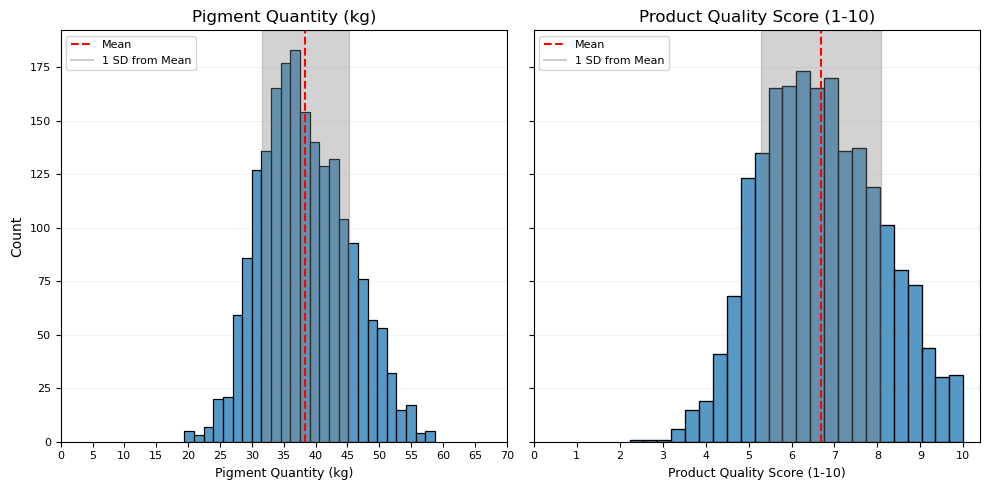

In [7]:
#Analyze distributions of 'pigment_quantity', 'product_quality_score'

#Calculate their means, standard deviations
product_quality = pd.DataFrame(data=orig_df.agg({'pigment_quantity':['mean','std'], 
                                               'product_quality_score':['mean','std']}).values.reshape(1,4),
                     columns=['pigment_quantity_mean', 'product_quality_score_mean', 'pigment_quantity_sd', 
                              'product_quality_score_sd'])
#Need to reorganize columns
product_quality = product_quality[['product_quality_score_mean', 'product_quality_score_sd', 'pigment_quantity_mean', 
                               'pigment_quantity_sd']]
#display(product_quality)


#Visualize the distributions
fig, axes = plt.subplots(ncols=2, figsize=(10,5), sharey=True)
ax1 = sns.histplot(data=orig_df, x='pigment_quantity', ax=axes[0])
ax2 = sns.histplot(data=orig_df, x='product_quality_score', ax=axes[1])

#edit plot details
for k,v in {'Pigment Quantity (kg)':[0, 71,5, product_quality['pigment_quantity_mean'][0],
                                    product_quality['pigment_quantity_sd'][0]],
            'Product Quality Score (1-10)':[1, 11,1, product_quality['product_quality_score_mean'][0], 
                                   product_quality['product_quality_score_sd'][0]]}.items():
    plt.sca(axes[v[0]])
    #add the mean
    plt.axvline(v[3], linestyle='--', color='red')
    #identify data within 1 standard deviation of the mean
    plt.axvspan(xmin=v[3]-v[4], xmax=v[3]+v[4], color='gray', edgecolor='black', alpha=0.35)
    
    plt.title(k)
    plt.xlabel(k, fontsize=9)
    plt.xticks(ticks=range(0,v[1],v[2]), fontsize=8)
    plt.yticks(ticks=range(0,176,25), fontsize=8)
    #add a legend
    red_line = mlines.Line2D([], [], color='red', linestyle='--', label='Mean')
    gray_range = mlines.Line2D([], [], color='gray', alpha=0.4, label='1 SD from Mean')
    plt.legend(handles=[red_line, gray_range], fontsize=8, loc='upper left')
    plt.grid(axis='y',alpha=0.1,color='gray')
    plt.tight_layout();

The figures above illustrate the distributions of the pigment quantities (in kilograms) & product quality scores (between 1-10) of colorants. There are 2,000 data points comprising this data. The vertical, dashed, red lines indicate the means of the distributions. The gray ranges indicate the data points that are within one standard deviation of the mean of each distribution.

The pigment-quantity distribution is fairly normal in that values fall around the mean in a mostly symmetrical way. The average colorant has about 38 kg of pigment & most have somewhere between 31-45 kg.  
The product-quality distribution is also somewhat normal but it has a stronger lean towards the left; it is left-skewed. As such, the mean (6.7) is slightly greater than the median (6.6) product quality score. Most scores are between 5.5-8.

,product_quality_score_mean,product_quality_score_sd,pigment_quantity_mean,pigment_quantity_sd,corr_coef
0,6.68,1.39,38.35,6.83,0.49


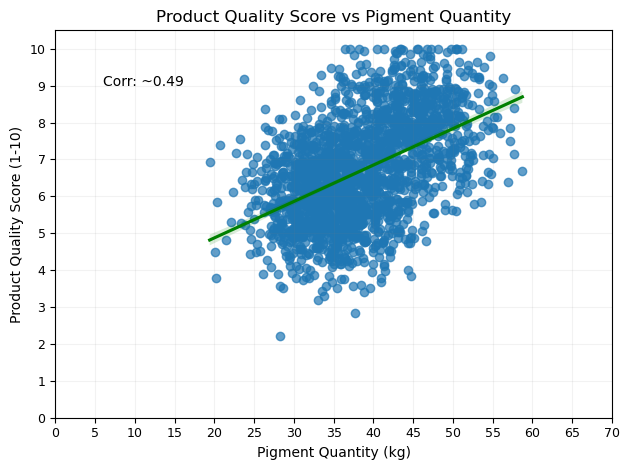

In [8]:
#Calculate correlation coefficients between 'pigment_quantity', 'product_quality_score'
quant_qual_corr = orig_df[['pigment_quantity','product_quality_score']].corr(method='pearson').iloc[0,1]
product_quality['corr_coef'] = quant_qual_corr

#Round all values to 2 decimals
product_quality = round(product_quality, 2)
display(product_quality)


#Visualize the data, display the regression line
ax1 = sns.regplot(data=orig_df, x='pigment_quantity', y='product_quality_score', scatter_kws={'alpha':0.7}, 
                  line_kws={'color':'green'})
#edit plot details
plt.title('Product Quality Score vs Pigment Quantity')
ax1.set(xlim=(0,70), ylim=(0,10.5))
plt.xlabel('Pigment Quantity (kg)')
plt.xticks(ticks=range(0,71,5), fontsize=9)
plt.ylabel('Product Quality Score (1-10)')
plt.yticks(ticks=range(0,11,1), fontsize=9)
#label the correlation of the relationship
plt.annotate(text=f"Corr: ~{round(quant_qual_corr, 2)}", xy=(6,9))
plt.grid(axis='both', alpha=0.1, color='gray')
plt.tight_layout();

The figure above displays product quality scores (on a scale from 1-10) against pigment quantities (in kilograms) of 2,000 colorants.

Spectrum Shades, in the interest of solving the issue of a growing number of complaints regarding inconsistent color quality in their products, wants to evaluate factors causing color variations & how they relate to product quality scores. Pigment quantity is one such variable.  
From the figure above & associated analyses, it appears that when more pigment is included in the business' colorants, customers are generally happier with the product. More specifically, the figure directly above shows a clear, linear relationship between these two variables, a relationship that possesses a weak-to-moderate, positive correlation of about 0.49. In other words, the more pigment that is put into the company's products, customers are typically more satisfied with it & indicate this through a higher product quality score. The green, diagonal line indicates more clearly how these variables change in relation to one another. To clarify, this metric does not indicate causation, but merely that the two variables change in relation to one another.

As such, this figure & the associated analyses offer an immediate solution for the company towards fixing their dillemma in a rising number of complaints with their products. By introducing more pigment into their products, Spectrum Shades is likely to see a rise in the quality scores of their products which should be accompanied by less complaints. Such an undertaking will hopefully begin to resolve the problem with low customer satisfaction.

When it comes to inconsistent color quality, a higher pigment concentration typically produces a brighter, more vivid result in colorants. It is unclear as to what exactly the problem of "inconsistent color quality" is, but products lacking a clear, rich, vibrant hue may be one aspect. If so, adding pigment could not only aid in the problem of low customer satisfaction but also in that of inconsistent color quality.  
If this problem does not have to do with the concentration of the business' colorants, then other factors will need to be analyzed. Perhaps such quality problems are arising due to pigment type, mixing time, mixing speed, material supplier, or how long between production & usage. Such variables, which are available in this dataset, could be evaluated against 'product_quality_score' to determine if there is any relationship. Even if there is not a meaningful relationship, the information is still valuable in that it can rule out such factors. Beyond these variables, other aspects of the production process could be analyzed such as the equipment utilized, the elements in which the material may be exposed to (i.e. air, metals), how it is stored, etc.

# FORMATTING AND NAMING CHECK
Use the code block below to check that your outputs are correctly named and formatted before you submit your project.

This code checks whether you have met our automarking requirements: that the specified DataFrames exist and contain the required columns. It then prints a table showing ✅ for each column that exists and ❌ for any that are missing, or if the DataFrame itself isn't available.

If a DataFrame or a column in a DataFrame doesn't exist, carefully check your code again.

IMPORTANT: even if your code passes the check below, this does not mean that your entire submission is correct. This is a check for naming and formatting only.

In [9]:
#Make a function to check the formatting & names of the primary output variables
def check_columns(output_df, output_df_name, required_columns):
    results = []
    for col in required_columns:
        exists = col in output_df.columns
        results.append({'Dataset': output_df_name, 'Column': col, 'Exists': '✅' if exists else '❌'})
    return results

def safe_check(output_df_name, required_columns):
    results = []
    if output_df_name in globals():
        obj = globals()[output_df_name]
        if isinstance(obj, pd.DataFrame):
            results.extend(check_columns(obj, output_df_name, required_columns))
        elif isinstance(obj, str) and ("SELECT" in obj.upper() or "FROM" in obj.upper()):
            results.append({'Dataset': output_df_name, 'Column': '—', 'Exists': 'ℹ️ SQL query string'})
        else:
            results.append({'Dataset': output_df_name, 'Column': '—', 'Exists': '❌ Not a DataFrame or query'})
    else:
        results.append({'Dataset': output_df_name, 'Column': '—', 'Exists': '❌ Variable not defined'})
    return results

requirements = {
    'clean_data': ['production_date', 'pigment_type', 'mixing_time', 'mixing_speed'],
    'aggregated_data': ['raw_material_supplier', 'avg_product_quality_score', 'avg_pigment_quantity'],
    'pigment_data': ['raw_material_supplier', 'pigment_quantity', 'avg_product_quality_score'],
    'product_quality': ['product_quality_score_mean', 'product_quality_score_sd',
                        'pigment_quantity_mean', 'pigment_quantity_sd', 'corr_coef']
}

all_results = []
for output_df_name, cols in requirements.items():
    all_results += safe_check(output_df_name, cols)

check_results_df = pd.DataFrame(all_results)

print(check_results_df)

            Dataset                      Column Exists
0        clean_data             production_date      ✅
1        clean_data                pigment_type      ✅
2        clean_data                 mixing_time      ✅
3        clean_data                mixing_speed      ✅
4   aggregated_data       raw_material_supplier      ✅
5   aggregated_data   avg_product_quality_score      ✅
6   aggregated_data        avg_pigment_quantity      ✅
7      pigment_data       raw_material_supplier      ✅
8      pigment_data            pigment_quantity      ✅
9      pigment_data   avg_product_quality_score      ✅
10  product_quality  product_quality_score_mean      ✅
11  product_quality    product_quality_score_sd      ✅
12  product_quality       pigment_quantity_mean      ✅
13  product_quality         pigment_quantity_sd      ✅
14  product_quality                   corr_coef      ✅
